# Model #

I try to put down a model. I will use the xor-perceptron model as a base and modify that.

first create the lattice, N by N, with Nsol = N**2

I should create a class for the cell object and then the network class is formed by cell objects and when the network is created, each network is associated with a position in the lattice.

Note: for now I'm only considering one possible link between each pair neuron for each direction

In [1]:
import numpy as np
from numpy import random as nrd
import matplotlib.pyplot as plt
import graph_tool as gt
from graph_tool.all import *
import copy

import model_ricard as m       # I've put all the functions in a separate Python file

In [2]:
# parameters of the simulation
par={'L': 8,                    # side length of the squared lattice
     'p_self_link': 0,         # probability for each cell of having a self link
     'C_density': 1,                       # initial density of links
     'J_range': [-1,+1],                       # define the possible value for J.
     'gamma': 2,                             # gamma parameter of the Boltzmann function (transfer function)
     'tau': 700,                                   # temperature parameter for the softmax 
     'crossover_ratio': 0,                    # percentage of offspring to be generated by crossover + mutation (instead of only mutation)
     'target_set': [-1.0,1.0,1.0,-1.0],
     'input_set':[[-1,-1],[-1,1],[1,-1],[1,1]],
     'majority_ratio': None,                       # output = np.mean(state[int(par['majority_ratio']*par['L']):-1]); if None, output = state[-1]
     'ff_iter': 4,                               # number of iterations the ff is executed for computing the output of a network (to reach the steady state)
     'J_mutation_radius': 0.05,                 # standard deviation of the normal distribution used to sample the mutation value for J.
     'B_mutation_radius': 0.05,            # standard deviation of the normal distribution used to sample the mutation value for B.
     'T_mutation_radius': 0.025,           # standard deviation of the normal distribution used to sample the mutation value for T = T_mutation_radius * L
     'reproduction_ratio': 0.3,          # percentage of offsprings to be generated by reproduction (the reamining by random generation)
     'elitist_ratio':0.5,
     #'x_n': np.linspace(-1,1,64),   # discretization of the input of the transfer function (last argmument 
                                   # is also the maximum number of non-zero coefficients in the DFT of the 
                                   # transfer function. it should be a power of 2 for best performance of fft)
     'n_iter': 2000,                    # number of iterations of the algorithm
     'N_sol': 200}                       # number of solutions (individuals, networks) considered in the simulation

if par['reproduction_ratio'] + par['elitist_ratio'] > 1:
     print(f'Error: expected sum of reproduction ratio and elitist ratio to be at maximum 1, but instead got {par[
          'reproduction_ratio']} + {par['elitist_ratio']} = {par['reproduction_ratio']+par['elitist_ratio']}')

#nrd.seed(1234)

In [ ]:
solutions, lmean, t_dist_mean, mean_weight_cost, loss_ev, mean_asp = m.evolution(par,verb=2,gen_verb=False,stat=True)

Iteration #0...
Mean loss: 1.000158159355767
Best loss: 1.0
Cumulative Best loss: 1.0
Mean link: 0.78359130859375
Iteration #10...
Mean loss: 1.0003742474246164
Best loss: 0.9999999225069276
Cumulative Best loss: 0.9999999225069276
Mean link: 0.763572998046875
Iteration #20...
Mean loss: 1.0003405282444535
Best loss: 0.99996999654965
Cumulative Best loss: 0.99996999654965
Mean link: 0.749561767578125
Iteration #30...
Mean loss: 1.0002719624689975
Best loss: 0.99996999654965
Cumulative Best loss: 0.99996999654965
Mean link: 0.737166748046875
Iteration #40...
Mean loss: 1.000365465571599
Best loss: 0.99996999654965
Cumulative Best loss: 0.99996999654965
Mean link: 0.729378662109375
Iteration #50...
Mean loss: 1.0001835803972075
Best loss: 0.99996999654965
Cumulative Best loss: 0.99996999654965
Mean link: 0.711484375
Iteration #60...
Mean loss: 1.0001974074940678
Best loss: 0.9999072234142072
Cumulative Best loss: 0.9999072234142072
Mean link: 0.699593505859375
Iteration #70...
Mean loss:

In [ ]:
loss_ev[:,-1]

array([0.07212004, 0.0644466 , 1.10732334, 1.00443976, 0.05467191,
       0.05556487, 1.62588277, 1.02071103, 0.02212073, 0.09497577,
       0.03387298, 0.01302976, 0.11385808, 0.07223492, 0.06668065,
       1.52585411, 0.06231337, 1.02354368, 1.59201879, 1.33261331,
       0.02508687, 0.03263883, 1.25355544, 0.06723073, 1.00080869,
       1.0002275 , 1.7551322 , 0.02026826, 0.12045639, 1.72580635,
       1.45972586, 0.06818176, 0.09025653, 1.48377198, 0.01213883,
       1.26409889, 1.19069668, 0.02732365, 0.04137982, 0.12810731,
       1.06194949, 1.6807072 , 1.02469033, 0.06637555, 0.03642554,
       0.03057514, 0.10202772, 0.02811718, 0.09966473, 0.03705525,
       0.00964889, 1.54077457, 0.03625698, 1.14359123, 0.05213045,
       0.07489198, 0.13531379, 0.05074151, 0.0508576 , 0.00990371,
       0.10271515, 0.03115728, 0.06554447, 1.19124532, 0.05492484,
       0.13909387, 0.07437159, 0.02706829, 0.07318282, 0.04478658,
       0.08127962, 0.02415096, 0.10801877, 0.01558117, 0.05277

In [ ]:
losses = []
for n,sol in enumerate(solutions[:10]):
    print(f'Solution #{n}')
    loss,_,_ = m.compute_loss(sol,par,verb=True)
    losses.append(loss)
    print(f'loss:{loss}')

Solution #0
Input: [-1, -1] -> Output: -0.9976628258103875
Input: [-1, 1] -> Output: 0.9195805950110998
Input: [1, -1] -> Output: 0.7598723380184589
Input: [1, 1] -> Output: -0.5263480854985088
loss:0.07212004331040264
Solution #1
Input: [-1, -1] -> Output: -0.9972955949721202
Input: [-1, 1] -> Output: 0.6273703917119884
Input: [1, -1] -> Output: 0.8346566212933932
Input: [1, 1] -> Output: -0.6973651803564349
loss:0.06444660143056034
Solution #2
Input: [-1, -1] -> Output: 0.32760241087146347
Input: [-1, 1] -> Output: 0.32760241087146347
Input: [1, -1] -> Output: 0.32760241087146347
Input: [1, 1] -> Output: 0.32760241087146347
loss:1.1073233396087951
Solution #3
Input: [-1, -1] -> Output: -0.06663156009768811
Input: [-1, 1] -> Output: -0.06663156009768811
Input: [1, -1] -> Output: -0.06663156009768811
Input: [1, 1] -> Output: -0.06663156009768811
loss:1.004439764801052
Solution #4
Input: [-1, -1] -> Output: -0.9940910377027058
Input: [-1, 1] -> Output: 0.8750348405069657
Input: [1, -1] 

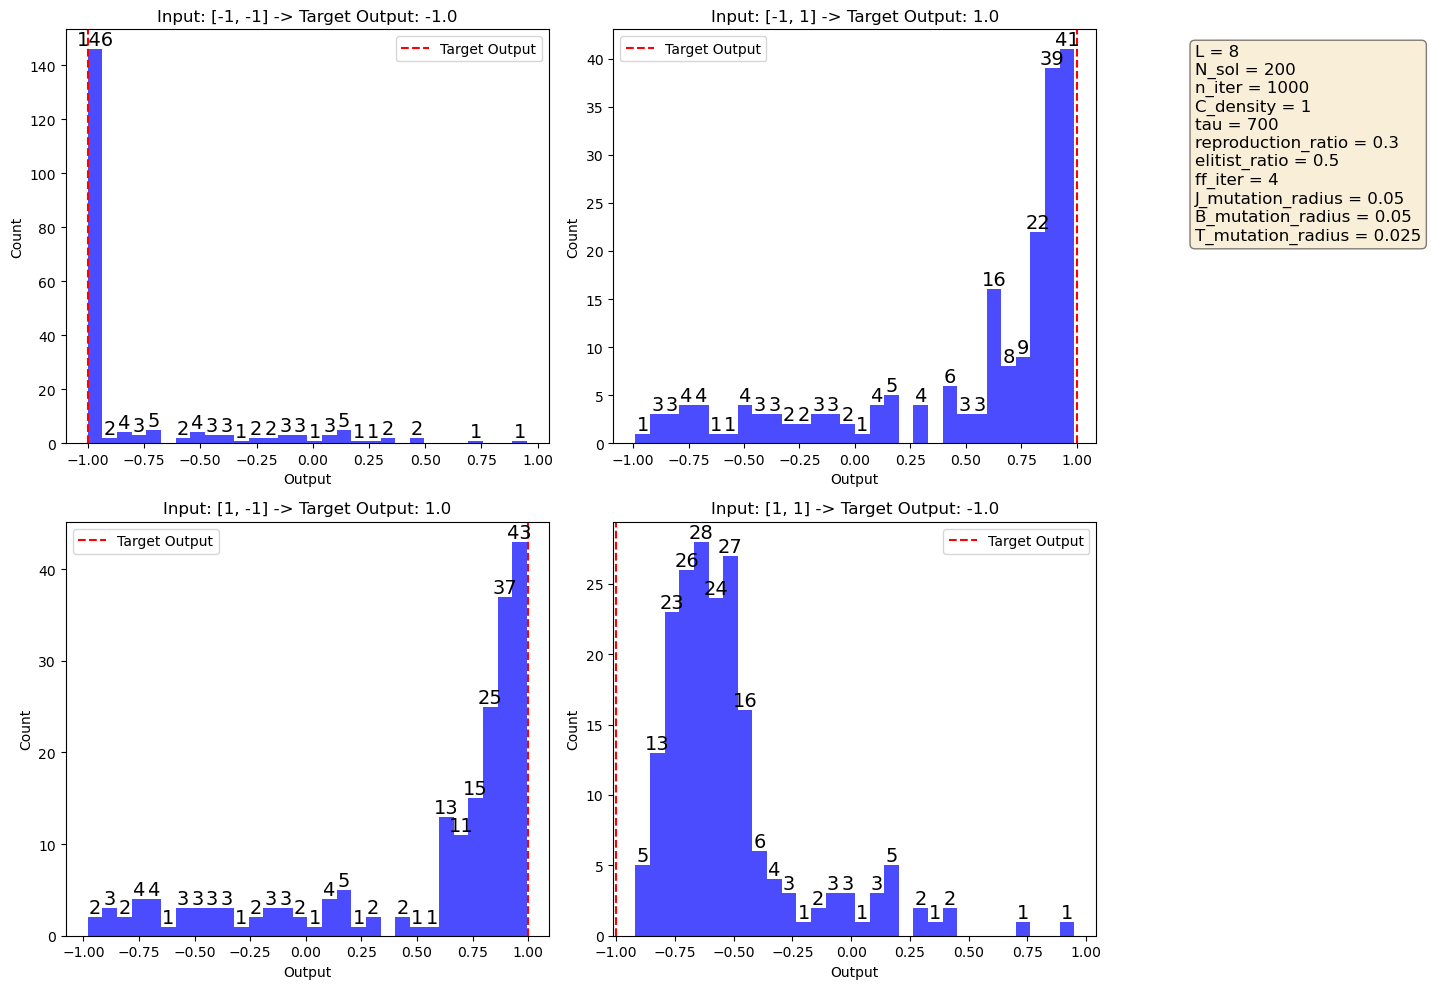

In [ ]:
outputs = np.zeros((len(solutions), len(par['input_set'])))
for n, sol in enumerate(solutions):
    for i, input in enumerate(par['input_set']):
        output = m.ff(input, sol, par)
        outputs[n, i] = output

fig, axes = plt.subplots(2, len(par['input_set']) // 2, figsize=(16, 10))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.hist(outputs[:, i], bins=30, alpha=0.7, color='b')
    ax.set_title(f'Input: {par["input_set"][i]} -> Target Output: {par["target_set"][i]}')
    ax.set_xlabel('Output')
    ax.set_ylabel('Count')
    ax.axvline(par['target_set'][i], label='Target Output', color='r', linestyle='--')
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        (patch.get_x() + patch.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=14)
    ax.legend()

# Prepare parameter text
param_text = (
    f"L = {par['L']}\n"
    f"N_sol = {par['N_sol']}\n"
    f"n_iter = {par['n_iter']}\n"
    f"C_density = {par['C_density']}\n"
    f"tau = {par['tau']}\n"
    f"reproduction_ratio = {par['reproduction_ratio']}\n"
    f"elitist_ratio = {par['elitist_ratio']}\n"
    f"ff_iter = {par['ff_iter']}\n"
    f"J_mutation_radius = {par['J_mutation_radius']}\n"
    f"B_mutation_radius = {par['B_mutation_radius']}\n"
    f"T_mutation_radius = {par['T_mutation_radius']}"
)

# Add parameter box
fig.text(0.75, 0.95, param_text, fontsize=12, va='top', ha='left',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout(rect=[0, 0, 0.7, 1])
plt.savefig('plots/IO.png')
plt.show()

Links density:0.055419921875


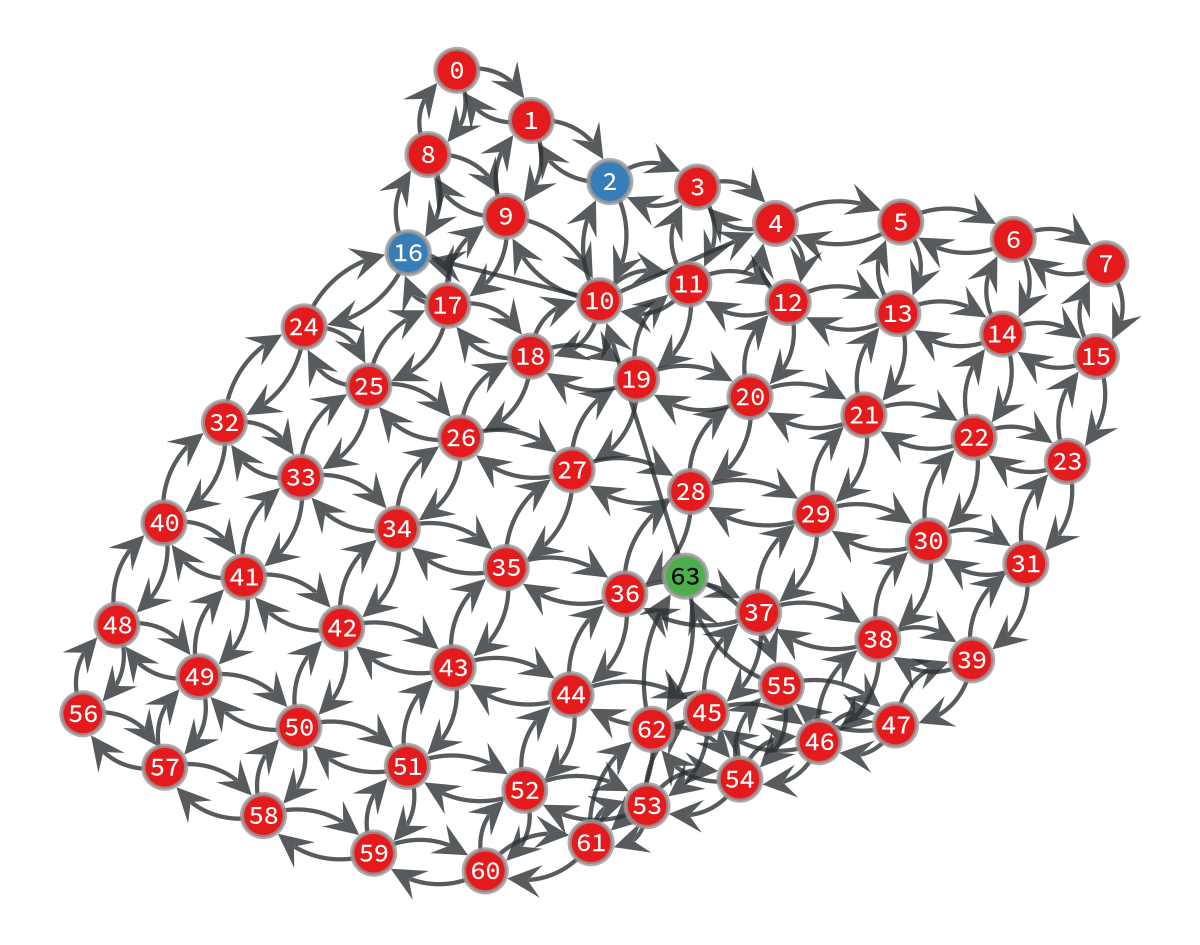

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7fcdc776c0f0, at 0x7fcdc77b9400>

In [ ]:
print(f'Links density:{np.sum(solutions[0].C)/solutions[0].C.shape[0]**2}')

graph = solutions[1].G

highlight = graph.new_vertex_property('int')
highlight[graph.vertex(2)] = 1
highlight[graph.vertex(2*par['L'])] = 1
if par['majority_ratio'] is not None:
    for i in range(int(par['majority_ratio']*(par['L']**2)),graph.num_vertices()):  # outputs
        highlight[graph.vertex(i)] = 2
else: 
    highlight[graph.vertex(par['L']**2-1)] = 2

graph_draw(
    graph,
    vertex_text=graph.vertex_index,
    vertex_fill_color=highlight,
    vcmap=plt.cm.Set1
)

In [ ]:
sol = sorted(solutions, key=lambda sol: sol.loss)
for i,input in enumerate(par['input_set']):
    output = m.ff(input,sol[0],par,verb=0)
    print(f'Input:{input} -> Output:{output} -- Expected:{par['target_set'][i]}')

Input:[-1, -1] -> Output:-0.9840610562457724 -- Expected:-1.0
Input:[-1, 1] -> Output:0.9798293324159371 -- Expected:1.0
Input:[1, -1] -> Output:0.9694001227108457 -- Expected:1.0
Input:[1, 1] -> Output:-0.8614238661086562 -- Expected:-1.0


Links density:0.055419921875


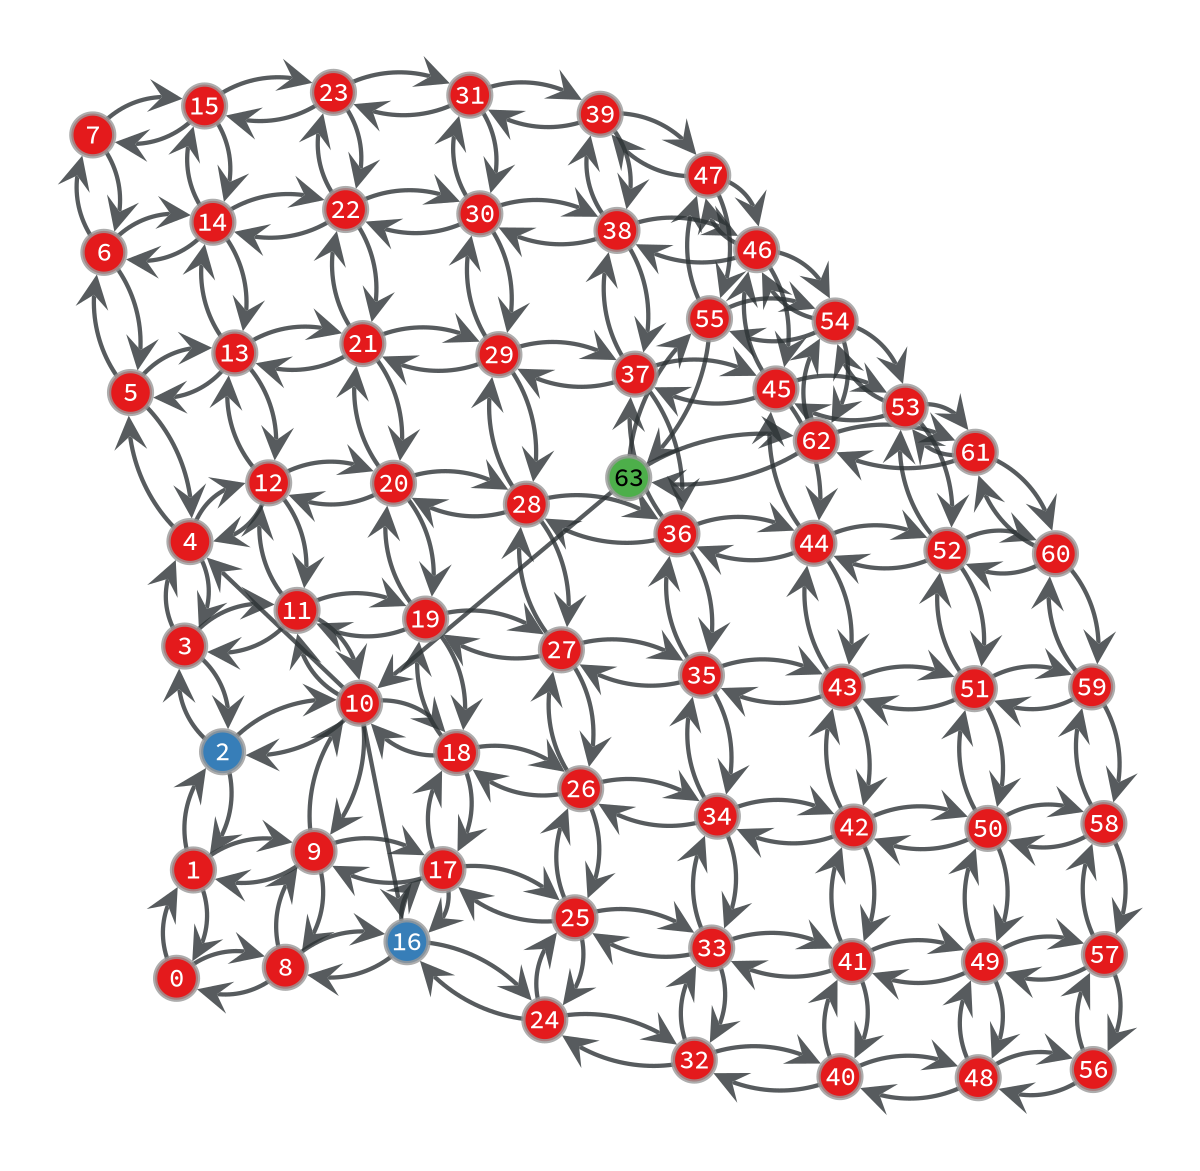

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7fcdc77aba70, at 0x7fcdc779a3c0>

In [ ]:
print(f'Links density:{np.sum(sol[0].C)/sol[0].C.shape[0]**2}')
graph = sol[0].G

highlight = graph.new_vertex_property('int')
highlight[graph.vertex(2)] = 1
highlight[graph.vertex(2*par['L'])] = 1
if par['majority_ratio'] is not None:
    for i in range(int(par['majority_ratio']*(par['L']**2)),graph.num_vertices()):  # outputs
        highlight[graph.vertex(i)] = 2
else: 
    highlight[graph.vertex(par['L']**2-1)] = 2

graph_draw(
    graph,
    vertex_text=graph.vertex_index,
    vertex_fill_color=highlight,
    vcmap=plt.cm.Set1
)

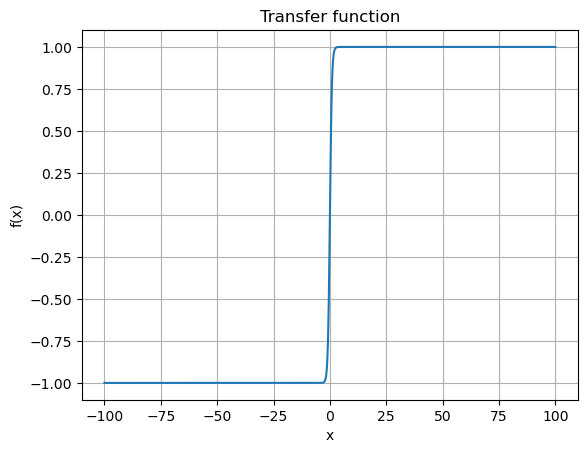

In [ ]:
m.plot_T(solutions[0].T[0],par)

In [ ]:
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(8, 6))

param_text = (
    f"L = {par['L']}\n"
    f"N_sol = {par['N_sol']}\n"
    f"n_iter = {par['n_iter']}\n"
    f"C_density = {par['C_density']}\n"
    f"tau = {par['tau']}\n"
    f"reproduction_ratio = {par['reproduction_ratio']}\n"
    f"elitist_ratio = {par['elitist_ratio']}\n"
    f"ff_iter = {par['ff_iter']}\n"
    f"J_mutation_radius = {par['J_mutation_radius']}\n"
    f"B_mutation_radius = {par['B_mutation_radius']}\n"
    f"T_mutation_radius = {par['T_mutation_radius']}"
)

# Move parameter box to the right and center vertically
fig.text(0.98, 0.5, param_text, fontsize=12, va='center', ha='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Use fixed bins for all frames to ensure visibility
bins = np.linspace(np.min(loss_ev), np.max(loss_ev), 50)

def animate(i):
    ax.clear()
    ax.hist(loss_ev[:, i], bins=bins, color='b', alpha=0.7)
    ax.set_title(f'Loss Histogram at Iteration {i+1}')
    ax.set_xlabel('Loss')
    ax.set_ylabel('Population')
    ax.set_xlim(np.min(loss_ev), np.max(loss_ev))
    ax.set_ylim(0, par['N_sol'])

ani = animation.FuncAnimation(fig, animate, frames=loss_ev.shape[1], interval=50)

ani.save('plots/loss_evolution.gif', writer='pillow')
plt.close(fig)

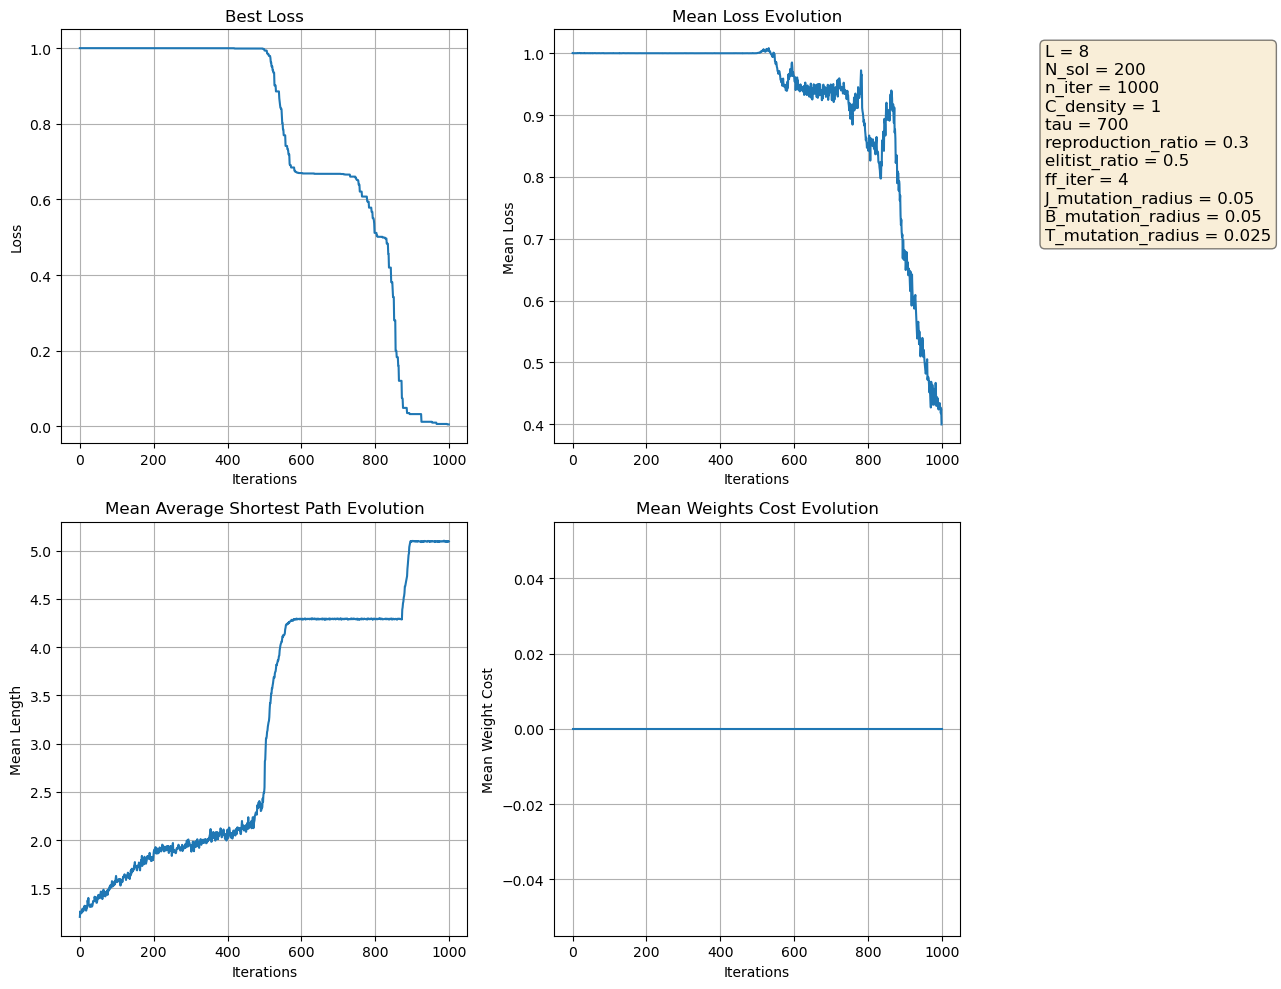

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Best Loss
best_loss = np.min(loss_ev, axis=0)
axs[0, 0].plot(best_loss)
axs[0, 0].set_title('Best Loss')
axs[0, 0].set_xlabel('Iterations')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].grid(True)

# Mean Loss Evolution
axs[0, 1].plot(np.arange(par['n_iter']), lmean)
axs[0, 1].set_title('Mean Loss Evolution')
axs[0, 1].set_xlabel('Iterations')
axs[0, 1].set_ylabel('Mean Loss')
#axs[0, 1].set_xscale('log')
axs[0, 1].grid(True)

# Mean Average Shortest Path Evolution
axs[1, 0].plot(mean_asp)
axs[1, 0].set_title('Mean Average Shortest Path Evolution')
axs[1, 0].set_xlabel('Iterations')
axs[1, 0].set_ylabel('Mean Length')
axs[1, 0].grid(True)

# Mean Volume Evolution
axs[1, 1].plot(mean_weight_cost)
axs[1, 1].set_title('Mean Weights Cost Evolution')
axs[1, 1].set_xlabel('Iterations')
axs[1, 1].set_ylabel('Mean Weight Cost')
#axs[1, 1].set_xscale('log')
axs[1, 1].grid(True)

# Prepare parameter text
param_text = (
    f"L = {par['L']}\n"
    f"N_sol = {par['N_sol']}\n"
    f"n_iter = {par['n_iter']}\n"
    f"C_density = {par['C_density']}\n"
    f"tau = {par['tau']}\n"
    f"reproduction_ratio = {par['reproduction_ratio']}\n"
    f"elitist_ratio = {par['elitist_ratio']}\n"
    f"ff_iter = {par['ff_iter']}\n"
    f"J_mutation_radius = {par['J_mutation_radius']}\n"
    f"B_mutation_radius = {par['B_mutation_radius']}\n"
    f"T_mutation_radius = {par['T_mutation_radius']}"
)

# Add parameter box
fig.text(0.75, 0.95, param_text, fontsize=12, va='top', ha='left',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout(rect=[0, 0, 0.7, 1])
plt.savefig('plots/loss.png')
plt.show()
